# Kitaev chain states - check

Created 03/06/2026

Objectives:
* Perform simple checks on Kitaev chain states calculated [here](../../save_states/kitaev_chain_200_site_dmrg.ipynb).

# Package imports

In [1]:
import sys
sys.path.append('../../')

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [25]:
from SPTOptimization.utils import to_npc_array

# Load data

In [5]:
DATA_DIR = r"../../data/kitaev_chain_200_site_dmrg/"

In [6]:
def parse_file_name(file_name):
    return int(file_name.split('_')[0])/100

In [9]:
loaded_data = dict()

for local_file_name in os.listdir(DATA_DIR):
    f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
    if f_name.endswith('.h5'):
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
    
            data_info = parse_file_name(local_file_name)
            loaded_data[data_info]=data['wavefunction']

In [11]:
loaded_data[0].expectation_value('N')

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [12]:
loaded_data[1].expectation_value('N')

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])

In [18]:
n_exps = np.array([
    psi.expectation_value('N', 50)[0]
    for psi in loaded_data.values()
])

In [19]:
n_exps

array([0.77422129, 0.60455954, 0.52208035, 0.93866411, 0.58454196,
       0.8885338 , 0.51389425, 0.5313114 , 0.55388434, 0.50657952,
       0.5       , 0.96710773, 0.70474289, 0.99861207, 0.9937688 ,
       1.        , 0.66116271, 0.98404511, 0.62932895, 0.56793478,
       0.54181287])

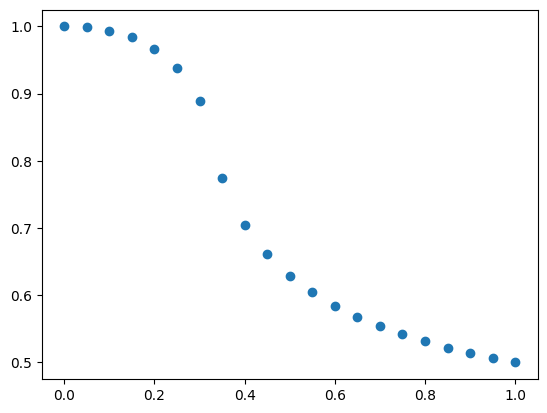

In [20]:
plt.plot(loaded_data.keys(), n_exps, 'o')

In [22]:
np_JW = np.array([
    [1, 0],
    [0, -1]
])

In [26]:
npc_JW = to_npc_array(np_JW)

In [32]:
fp_exps = np.array([
    psi.expectation_value([npc_JW,]*100, sites=0)[0]
    for psi in loaded_data.values()
])

In [31]:
fp_exps.shape

(21, 1)

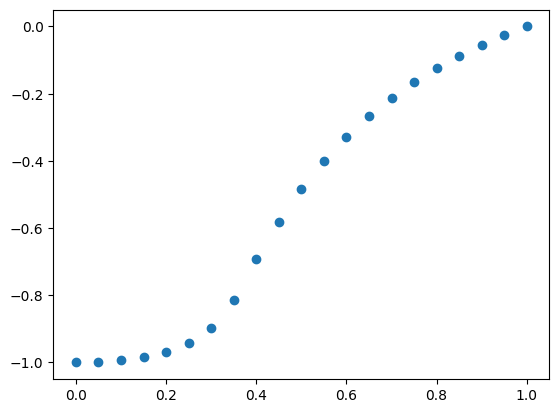

In [33]:
plt.plot(loaded_data.keys(), fp_exps, 'o')

# Conclusions
Aligns with expectations.